# TP : Régression logistique sous Python

**Cas d'étude :** Prédiction de la maladie cardio-vasculaire (Cleveland Heart Disease)
**Cours :** Modèle linéaire généralisé — Mme F. BADAOUI (INSEA)
**Environnement :** conda `datasci` (Python 3.11)

Ce notebook applique pas-à-pas la démarche du cours :
1. Analyse descriptive
2. Échantillonnage stratifié 80 / 20
3. Ajustement d'un GLM Binomial(link=logit) par maximum de vraisemblance
4. Tests de Wald / rapport de vraisemblance / Pearson
5. Adéquation (déviance, Hosmer-Lemeshow, pseudo-R², AIC)
6. Résidus (Pearson, déviance, leviers, Cook)
7. Comparaison des modèles (matrice de confusion, ROC)

## 0. Imports et configuration

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.genmod.families import Binomial
from statsmodels.genmod.families.links import logit, probit, cloglog
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, roc_curve, auc,
    accuracy_score, precision_score, recall_score, f1_score,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

ROOT = os.path.dirname(os.path.abspath("__file__"))
# Fallback pour Jupyter (pas de __file__)
if not ROOT or ROOT == "/":
    ROOT = os.getcwd()
FIG = os.path.join(ROOT, "figures")
DATA = os.path.join(ROOT, "data", "heart_cleveland.csv")
os.makedirs(FIG, exist_ok=True)

## 1. Chargement et préparation des données

Le jeu de données **Cleveland Heart Disease** de l'UCI Machine Learning
Repository comporte 303 patients caractérisés par 13 variables cliniques.
La variable réponse `num` ∈ {0, 1, 2, 3, 4} est dichotomisée en
`chd` = 1{num > 0}.

In [2]:
cols = ["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
        "thalach", "exang", "oldpeak", "slope", "ca", "thal", "num"]

df = pd.read_csv(DATA, header=None, names=cols, na_values="?")
print(f"Dimensions brutes : {df.shape}")
print(f"Valeurs manquantes par variable :")
print(df.isna().sum())

df = df.dropna().reset_index(drop=True)
print(f"\nAprès suppression des NA : {df.shape}")

# Variable réponse binaire
df["chd"] = (df["num"] > 0).astype(int)
df = df.drop(columns=["num"])

# Recodage des qualitatives (cf. cours p. 153 et suiv.)
df["sex"] = df["sex"].map({0: "F", 1: "M"})
df["cp"] = df["cp"].map({1: "angine_typ", 2: "angine_atyp",
                          3: "non_angineuse", 4: "asymptomatique"})
df["fbs"] = df["fbs"].map({0: "non", 1: "oui"})
df["restecg"] = df["restecg"].map({0: "normal", 1: "anomalie_ST_T",
                                    2: "hypertrophie_VG"})
df["exang"] = df["exang"].map({0: "non", 1: "oui"})
df["slope"] = df["slope"].map({1: "ascendante", 2: "plate", 3: "descendante"})
df["thal"] = df["thal"].map({3.0: "normal", 6.0: "fixe", 7.0: "reversible"})

df.head()

Dimensions brutes : (303, 14)
Valeurs manquantes par variable :
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64

Après suppression des NA : (297, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,chd
0,63.0,M,angine_typ,145.0,233.0,oui,hypertrophie_VG,150.0,non,2.3,descendante,0.0,fixe,0
1,67.0,M,asymptomatique,160.0,286.0,non,hypertrophie_VG,108.0,oui,1.5,plate,3.0,normal,1
2,67.0,M,asymptomatique,120.0,229.0,non,hypertrophie_VG,129.0,oui,2.6,plate,2.0,reversible,1
3,37.0,M,non_angineuse,130.0,250.0,non,normal,187.0,non,3.5,descendante,0.0,normal,0
4,41.0,F,angine_atyp,130.0,204.0,non,hypertrophie_VG,172.0,non,1.4,ascendante,0.0,normal,0


In [3]:
df.describe().round(2)

,age,trestbps,chol,thalach,oldpeak,ca,chd
count,297.00,297.00,297.00,297.00,297.00,297.00,297.00
mean,54.54,131.69,247.35,149.60,1.06,0.68,0.46
std,9.05,17.76,52.00,22.94,1.17,0.94,0.50
min,29.00,94.00,126.00,71.00,0.00,0.00,0.00
25%,48.00,120.00,211.00,133.00,0.00,0.00,0.00
50%,56.00,130.00,243.00,153.00,0.80,0.00,0.00
75%,61.00,140.00,276.00,166.00,1.60,1.00,1.00
max,77.00,200.00,564.00,202.00,6.20,3.00,1.00


## 2. Analyse descriptive

Avant la découpe stratifiée, il faut vérifier que la variable réponse n'est
pas fortement déséquilibrée.

In [4]:
print(df["chd"].value_counts())
print(f"\nProportion de malades : {df['chd'].mean():.3f}")
print(f"Proportion de sains   : {1 - df['chd'].mean():.3f}")

chd
0    160
1    137
Name: count, dtype: int64

Proportion de malades : 0.461
Proportion de sains   : 0.539


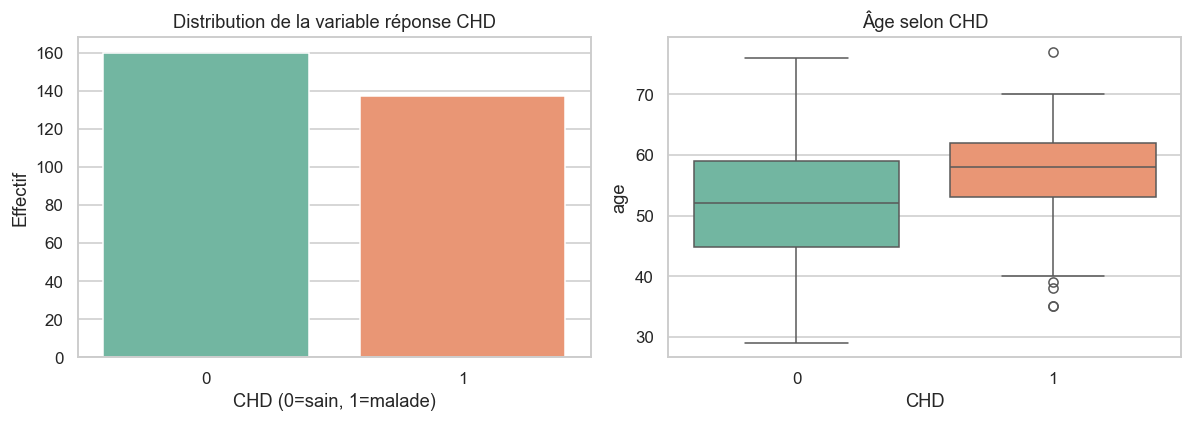

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(x="chd", data=df, ax=axes[0], palette="Set2")
axes[0].set_title("Distribution de la variable réponse CHD")
axes[0].set_xlabel("CHD (0=sain, 1=malade)")
axes[0].set_ylabel("Effectif")

sns.boxplot(x="chd", y="age", data=df, ax=axes[1], palette="Set2")
axes[1].set_title("Âge selon CHD")
axes[1].set_xlabel("CHD")
plt.tight_layout()
plt.savefig(os.path.join(FIG, "01_distribution_reponse.png"))
plt.show()

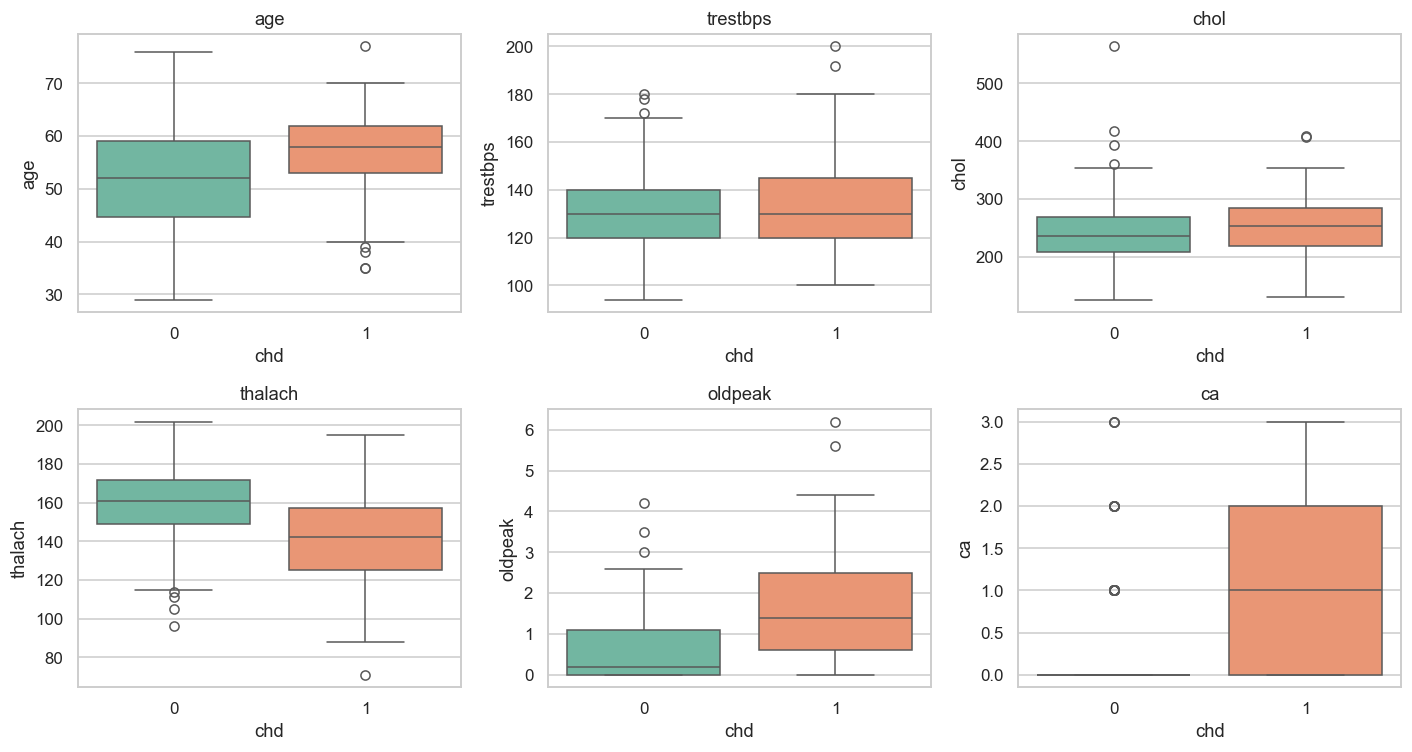

In [6]:
quant = ["age", "trestbps", "chol", "thalach", "oldpeak", "ca"]
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, c in zip(axes.flatten(), quant):
    sns.boxplot(x="chd", y=c, data=df, ax=ax, palette="Set2")
    ax.set_title(c)
plt.tight_layout()
plt.savefig(os.path.join(FIG, "02_quantitatives_vs_chd.png"))
plt.show()

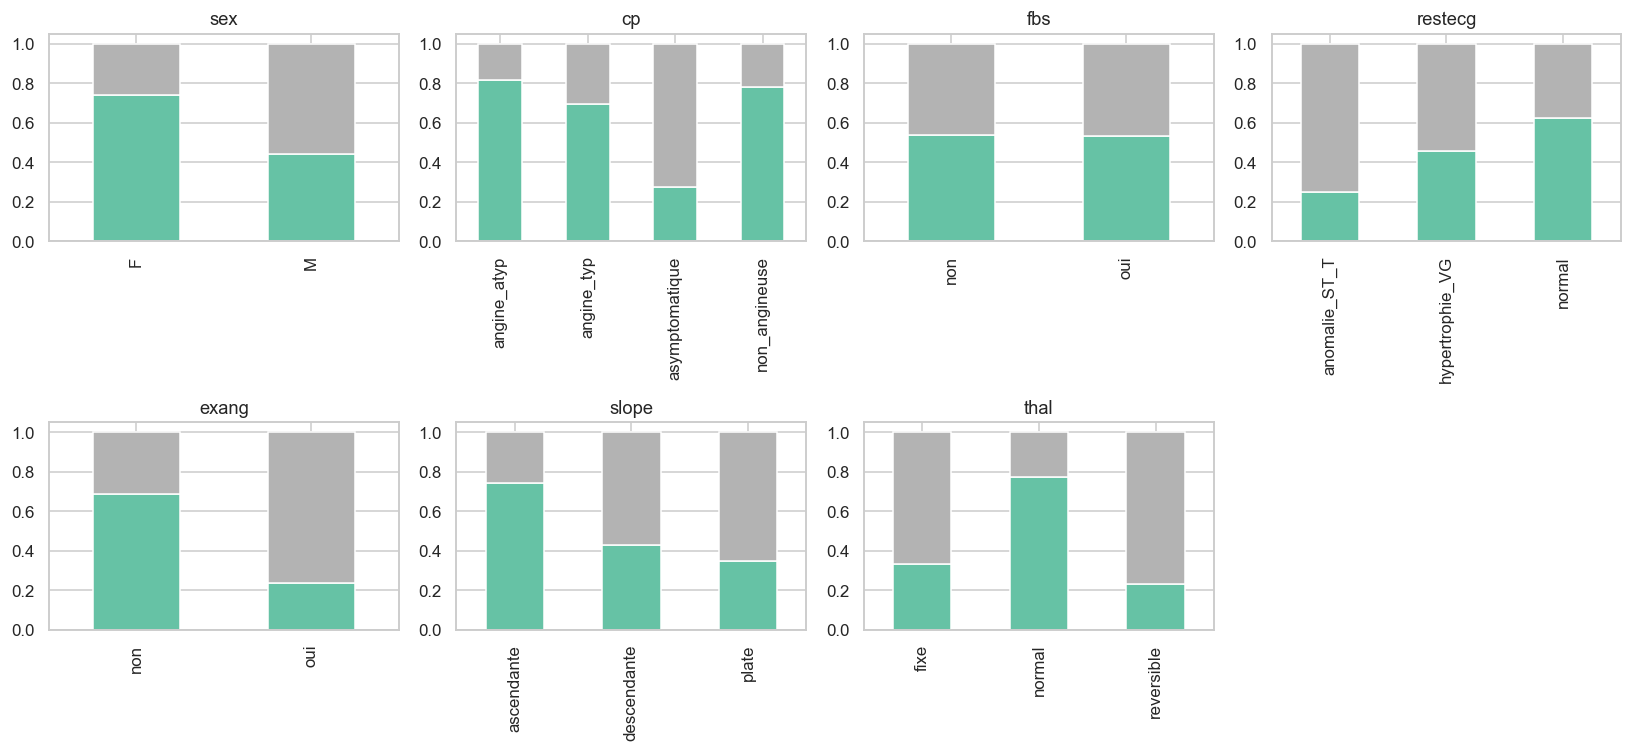

In [7]:
qual = ["sex", "cp", "fbs", "restecg", "exang", "slope", "thal"]
fig, axes = plt.subplots(2, 4, figsize=(15, 7))
for ax, c in zip(axes.flatten(), qual):
    pd.crosstab(df[c], df["chd"], normalize="index").plot(
        kind="bar", stacked=True, ax=ax, colormap="Set2", legend=False)
    ax.set_title(c)
    ax.set_xlabel("")
axes.flatten()[-1].axis("off")
plt.tight_layout()
plt.savefig(os.path.join(FIG, "03_qualitatives_vs_chd.png"))
plt.show()

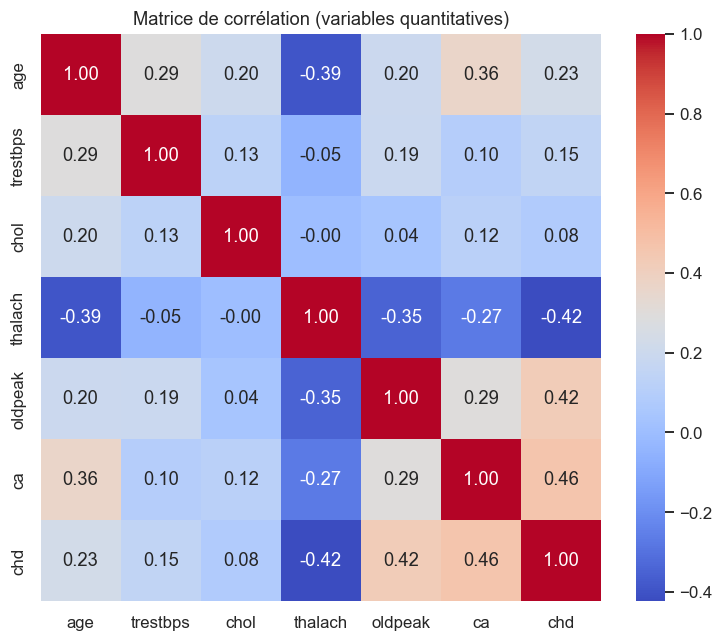

In [8]:
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(df[quant + ["chd"]].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", ax=ax)
ax.set_title("Matrice de corrélation (variables quantitatives)")
plt.tight_layout()
plt.savefig(os.path.join(FIG, "04_correlation.png"))
plt.show()

## 3. Échantillonnage stratifié 80 / 20

Conformément au cours, on préserve la répartition de la variable réponse
dans les deux sous-échantillons grâce à l'option `stratify=y`.

In [9]:
X_full = pd.get_dummies(
    df.drop(columns="chd"),
    columns=qual, drop_first=True
).astype(float)
y_full = df["chd"].astype(int).values

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.20, stratify=y_full, random_state=42
)
print(f"Apprentissage : {X_train.shape}, prop CHD = {y_train.mean():.3f}")
print(f"Validation    : {X_test.shape}, prop CHD = {y_test.mean():.3f}")

# Standardisation des continues
scaler = StandardScaler()
X_train[quant] = scaler.fit_transform(X_train[quant])
X_test[quant] = scaler.transform(X_test[quant])

X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)[X_train_sm.columns]
X_train_sm.head()

Apprentissage : (237, 18), prop CHD = 0.460
Validation    : (60, 18), prop CHD = 0.467


,const,age,trestbps,chol,thalach,oldpeak,ca,sex_M,cp_angine_typ,cp_asymptomatique,cp_non_angineuse,fbs_oui,restecg_hypertrophie_VG,restecg_normal,exang_oui,slope_descendante,slope_plate,thal_normal,thal_reversible
55,1.0,-0.085668,-0.462582,0.312737,-1.827448,0.967117,0.349404,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0
159,1.0,-0.973247,-1.749078,-0.987921,0.275439,-0.901878,-0.740185,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
176,1.0,-1.306090,-0.126974,1.236393,0.543892,0.712254,0.349404,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
86,1.0,-0.862300,0.320503,0.143086,0.275439,-0.901878,-0.740185,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
79,1.0,0.358121,0.991719,0.388137,-1.737964,-0.222243,-0.740185,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0


## 4. Ajustement du GLM Binomial, lien logit — modèle complet

Équivalent Python de `glm(chd ~ ., family=binomial(link="logit"))` :

In [10]:
m_full = sm.GLM(y_train, X_train_sm, family=Binomial(link=logit())).fit()
print(m_full.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                  237
Model:                            GLM   Df Residuals:                      218
Model Family:                Binomial   Df Model:                           18
Link Function:                  logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -80.141
Date:                Wed, 22 Apr 2026   Deviance:                       160.28
Time:                        21:05:30   Pearson chi2:                     267.
No. Iterations:                     6   Pseudo R-squ. (CS):             0.5052
Covariance Type:            nonrobust                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

## 5. Sélection de variables *backward AIC*

Critère : $\text{AIC} = -2\ell(\hat\beta) + 2p$, le plus faible est
préféré (cf. cours p. 117).

In [11]:
def backward_aic(X, y, verbose=False):
    cur = list(X.columns)
    best_aic = sm.GLM(y, X[cur], family=Binomial(link=logit())).fit().aic
    improved = True
    while improved and len(cur) > 1:
        improved = False
        scores = []
        for c in cur:
            if c == "const":
                continue
            trial = [k for k in cur if k != c]
            try:
                a = sm.GLM(y, X[trial], family=Binomial(link=logit())).fit().aic
                scores.append((a, c))
            except Exception:
                continue
        scores.sort()
        if scores and scores[0][0] < best_aic - 1e-3:
            best_aic = scores[0][0]
            cur.remove(scores[0][1])
            if verbose:
                print(f"  - retire {scores[0][1]:<28s}  AIC={best_aic:.3f}")
            improved = True
    return cur


sel = backward_aic(X_train_sm, y_train, verbose=True)
print(f"\nVariables retenues ({len(sel)-1}) : {[c for c in sel if c != 'const']}")

  - retire restecg_hypertrophie_VG       AIC=196.282
  - retire age                           AIC=194.284
  - retire thal_normal                   AIC=192.302
  - retire thalach                       AIC=191.002
  - retire fbs_oui                       AIC=189.816
  - retire chol                          AIC=188.833
  - retire slope_descendante             AIC=187.902
  - retire exang_oui                     AIC=187.535
  - retire cp_angine_typ                 AIC=187.145
  - retire cp_non_angineuse              AIC=186.195

Variables retenues (8) : ['trestbps', 'oldpeak', 'ca', 'sex_M', 'cp_asymptomatique', 'restecg_normal', 'slope_plate', 'thal_reversible']


In [12]:
m_red = sm.GLM(y_train, X_train_sm[sel], family=Binomial(link=logit())).fit()
print(m_red.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                  237
Model:                            GLM   Df Residuals:                      228
Model Family:                Binomial   Df Model:                            8
Link Function:                  logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -84.097
Date:                Wed, 22 Apr 2026   Deviance:                       168.19
Time:                        21:05:30   Pearson chi2:                     249.
No. Iterations:                     6   Pseudo R-squ. (CS):             0.4884
Covariance Type:            nonrobust                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -2.3709      0.59

In [13]:
m_age = sm.GLM(y_train, X_train_sm[["const", "age"]],
               family=Binomial(link=logit())).fit()
print(m_age.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                  237
Model:                            GLM   Df Residuals:                      235
Model Family:                Binomial   Df Model:                            1
Link Function:                  logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -158.74
Date:                Wed, 22 Apr 2026   Deviance:                       317.48
Time:                        21:05:30   Pearson chi2:                     237.
No. Iterations:                     4   Pseudo R-squ. (CS):            0.03949
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1683      0.133     -1.264      0.2

## 6. Test du rapport de vraisemblance (modèles emboîtés)

Sous $H_0$ : le modèle réduit est adéquat,
$\Delta D = D_{\text{réduit}} - D_{\text{complet}} \sim \chi^2_{p_1 - p_0}$.

In [14]:
def lr_test(small, big, name1, name2):
    stat = small.deviance - big.deviance
    ddl = int(small.df_resid - big.df_resid)
    p = 1 - stats.chi2.cdf(stat, ddl)
    print(f"H0: {name1}  vs  H1: {name2}")
    print(f"  ΔD = {stat:.4f},  ddl = {ddl},  p-value = {p:.5g}")
    print(f"  → {'H0 rejetée' if p < 0.05 else 'H0 conservée'} au seuil 5%\n")


lr_test(m_age, m_red, "M_age", "M_reduit")
lr_test(m_red, m_full, "M_reduit", "M_complet")

H0: M_age  vs  H1: M_reduit
  ΔD = 149.2828,  ddl = 7,  p-value = 0
  → H0 rejetée au seuil 5%

H0: M_reduit  vs  H1: M_complet
  ΔD = 7.9131,  ddl = 10,  p-value = 0.63732
  → H0 conservée au seuil 5%



## 7. Adéquation : déviance, Pearson, pseudo-R², AIC, BIC, Hosmer-Lemeshow

In [15]:
def adequation(model, y, name):
    n = len(y)
    p = int(model.df_model)
    D = model.deviance
    ddl = int(model.df_resid)
    pchi2 = float(((y - model.fittedvalues) ** 2 /
                   (model.fittedvalues * (1 - model.fittedvalues))).sum())
    pseudoR2 = 1 - model.deviance / model.null_deviance
    print(f"--- {name} ---")
    print(f"  n = {n}, p = {p}, ddl résiduels = {ddl}")
    print(f"  Déviance D        = {D:.4f}  (ratio D/ddl = {D/ddl:.3f})")
    print(f"  χ² Pearson        = {pchi2:.4f}  (ratio = {pchi2/ddl:.3f})")
    print(f"  Déviance nulle D0 = {model.null_deviance:.4f}")
    print(f"  Pseudo-R² (déviance) = {pseudoR2:.4f}")
    print(f"  AIC = {model.aic:.3f}   BIC = {model.bic_llf:.3f}")
    p_dev = 1 - stats.chi2.cdf(D, ddl)
    print(f"  Test de déviance : p = {p_dev:.4g} "
          f"({'adéquat' if p_dev > 0.05 else 'inadéquat'})\n")


adequation(m_age, y_train, "M_age")
adequation(m_red, y_train, "M_reduit")
adequation(m_full, y_train, "M_complet")

--- M_age ---
  n = 237, p = 1, ddl résiduels = 235
  Déviance D        = 317.4775  (ratio D/ddl = 1.351)
  χ² Pearson        = 236.9542  (ratio = 1.008)
  Déviance nulle D0 = 327.0269
  Pseudo-R² (déviance) = 0.0292
  AIC = 321.478   BIC = 328.414
  Test de déviance : p = 0.0002673 (inadéquat)

--- M_reduit ---
  n = 237, p = 8, ddl résiduels = 228
  Déviance D        = 168.1947  (ratio D/ddl = 0.738)
  χ² Pearson        = 248.7054  (ratio = 1.091)
  Déviance nulle D0 = 327.0269
  Pseudo-R² (déviance) = 0.4857
  AIC = 186.195   BIC = 217.407
  Test de déviance : p = 0.9989 (adéquat)

--- M_complet ---
  n = 237, p = 18, ddl résiduels = 218
  Déviance D        = 160.2816  (ratio D/ddl = 0.735)
  χ² Pearson        = 267.0622  (ratio = 1.225)
  Déviance nulle D0 = 327.0269
  Pseudo-R² (déviance) = 0.5099
  AIC = 198.282   BIC = 264.175
  Test de déviance : p = 0.9987 (adéquat)



In [16]:
def hosmer_lemeshow(y_true, y_prob, g=10):
    """Test de Hosmer-Lemeshow (cours p. 165-166). C² ~ χ²(g-2) sous H0."""
    df_ = pd.DataFrame({"y": y_true, "p": y_prob})
    df_["bin"] = pd.qcut(df_["p"], q=g, duplicates="drop")
    obs = df_.groupby("bin")["y"].agg(["sum", "count"])
    pi_ = df_.groupby("bin")["p"].mean().values
    o1 = obs["sum"].values
    n_ = obs["count"].values
    e1 = n_ * pi_
    C = np.sum((o1 - e1) ** 2 / (n_ * pi_ * (1 - pi_)))
    ddl = len(o1) - 2
    p = 1 - stats.chi2.cdf(C, ddl)
    return C, ddl, p


C, ddl_hl, p_hl = hosmer_lemeshow(y_train, m_red.fittedvalues, g=10)
print(f"Hosmer-Lemeshow (M_reduit, g=10) : C² = {C:.4f},  ddl = {ddl_hl},  p = {p_hl:.4g}")
print("→ p > 0.05 : hypothèse d'adéquation non rejetée.")

Hosmer-Lemeshow (M_reduit, g=10) : C² = 6.3668,  ddl = 8,  p = 0.6062
→ p > 0.05 : hypothèse d'adéquation non rejetée.


## 8. Analyse des résidus : Pearson, déviance, leviers, Cook

In [17]:
infl = m_red.get_influence()
res_p = m_red.resid_pearson
res_d = m_red.resid_deviance
lev = infl.hat_matrix_diag
cook = infl.cooks_distance[0]

seuil_h = 2 * (m_red.df_model + 1) / len(y_train)
print(f"|résidus de Pearson|  > 2 : {(np.abs(res_p) > 2).sum()} obs")
print(f"|résidus de déviance| > 2 : {(np.abs(res_d) > 2).sum()} obs")
print(f"Seuil de levier 2(p+1)/n = {seuil_h:.4f} : "
      f"{(lev > seuil_h).sum()} obs influentes")
print(f"Distance de Cook max = {cook.max():.4f}  (alerte si > 1)")

|résidus de Pearson|  > 2 : 13 obs
|résidus de déviance| > 2 : 6 obs
Seuil de levier 2(p+1)/n = 0.0759 : 24 obs influentes
Distance de Cook max = 0.0729  (alerte si > 1)


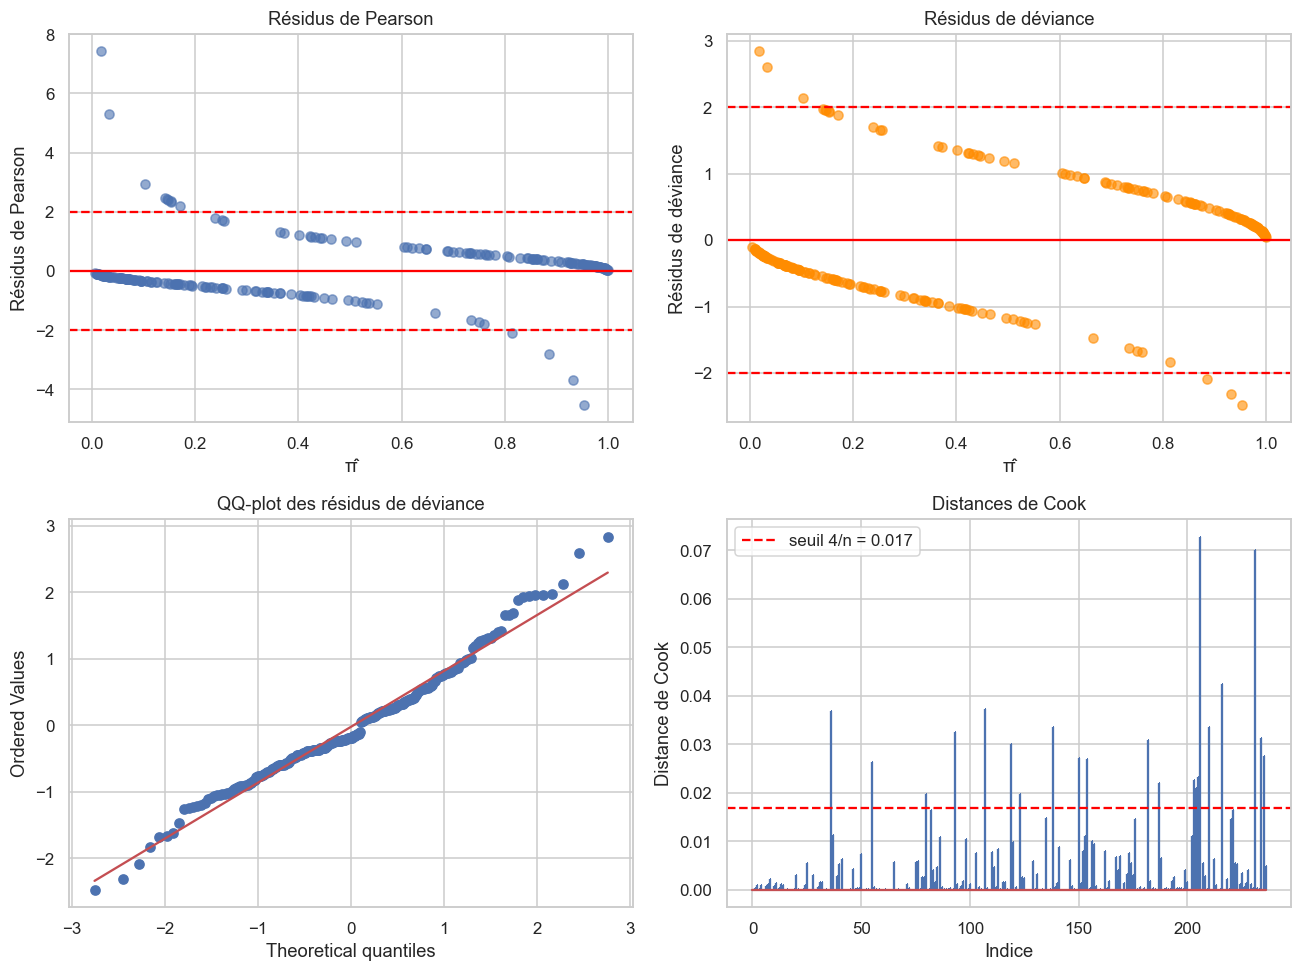

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes[0, 0].scatter(m_red.fittedvalues, res_p, alpha=0.6)
for y_line in (0, 2, -2):
    axes[0, 0].axhline(y_line, c="red", ls="--" if y_line else "-")
axes[0, 0].set_xlabel("π̂")
axes[0, 0].set_ylabel("Résidus de Pearson")
axes[0, 0].set_title("Résidus de Pearson")

axes[0, 1].scatter(m_red.fittedvalues, res_d, alpha=0.6, c="darkorange")
for y_line in (0, 2, -2):
    axes[0, 1].axhline(y_line, c="red", ls="--" if y_line else "-")
axes[0, 1].set_xlabel("π̂")
axes[0, 1].set_ylabel("Résidus de déviance")
axes[0, 1].set_title("Résidus de déviance")

stats.probplot(res_d, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title("QQ-plot des résidus de déviance")

axes[1, 1].stem(np.arange(len(cook)), cook, markerfmt=",")
axes[1, 1].axhline(4 / len(y_train), c="red", ls="--",
                   label=f"seuil 4/n = {4/len(y_train):.3f}")
axes[1, 1].set_xlabel("Indice")
axes[1, 1].set_ylabel("Distance de Cook")
axes[1, 1].set_title("Distances de Cook")
axes[1, 1].legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG, "05_residus.png"))
plt.show()

## 9. Évaluation sur l'échantillon de validation

Matrice de confusion, précision/rappel/F1 et **courbe ROC**.

In [19]:
def evaluate(model, X_te, y_te, name, seuil=0.5):
    p_hat = model.predict(X_te)
    y_hat = (p_hat >= seuil).astype(int)
    cm = confusion_matrix(y_te, y_hat)
    acc = accuracy_score(y_te, y_hat)
    prec = precision_score(y_te, y_hat, zero_division=0)
    rec = recall_score(y_te, y_hat)
    f1 = f1_score(y_te, y_hat)
    fpr, tpr, _ = roc_curve(y_te, p_hat)
    a = auc(fpr, tpr)
    print(f"\n--- {name} (seuil = {seuil}) ---")
    print(f"Matrice de confusion :\n{cm}")
    print(f"  Accuracy={acc:.3f}  Précision={prec:.3f}  "
          f"Rappel={rec:.3f}  F1={f1:.3f}  AUC={a:.3f}")
    return {"name": name, "cm": cm, "fpr": fpr, "tpr": tpr,
            "auc": a, "acc": acc, "f1": f1}


eval_full = evaluate(m_full, X_test_sm, y_test, "M_complet")
eval_red = evaluate(m_red, X_test_sm[sel], y_test, "M_reduit")
eval_age = evaluate(m_age, X_test_sm[["const", "age"]], y_test, "M_age")


--- M_complet (seuil = 0.5) ---
Matrice de confusion :
[[28  4]
 [ 6 22]]
  Accuracy=0.833  Précision=0.846  Rappel=0.786  F1=0.815  AUC=0.951

--- M_reduit (seuil = 0.5) ---
Matrice de confusion :
[[27  5]
 [ 6 22]]
  Accuracy=0.817  Précision=0.815  Rappel=0.786  F1=0.800  AUC=0.942

--- M_age (seuil = 0.5) ---
Matrice de confusion :
[[27  5]
 [17 11]]
  Accuracy=0.633  Précision=0.688  Rappel=0.393  F1=0.500  AUC=0.705


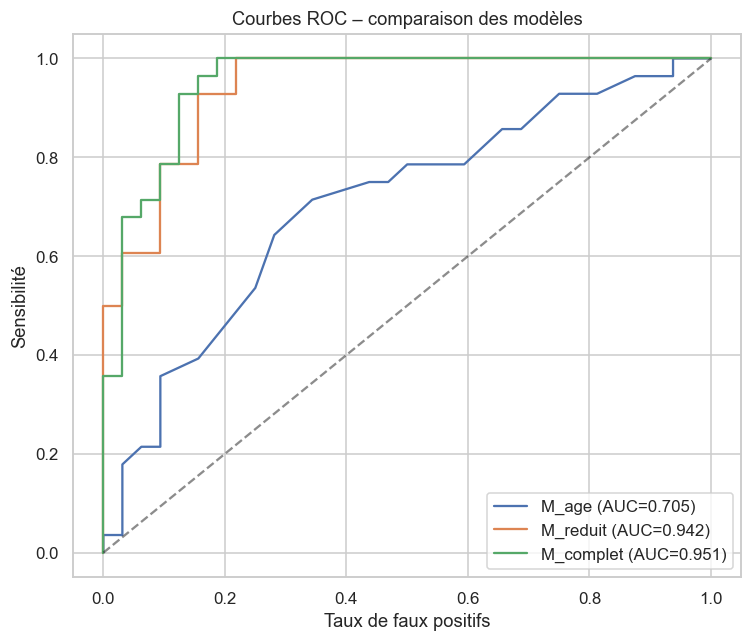

In [20]:
fig, ax = plt.subplots(figsize=(7, 6))
for r in [eval_age, eval_red, eval_full]:
    ax.plot(r["fpr"], r["tpr"], label=f"{r['name']} (AUC={r['auc']:.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.5)
ax.set_xlabel("Taux de faux positifs")
ax.set_ylabel("Sensibilité")
ax.set_title("Courbes ROC – comparaison des modèles")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join(FIG, "06_roc.png"))
plt.show()

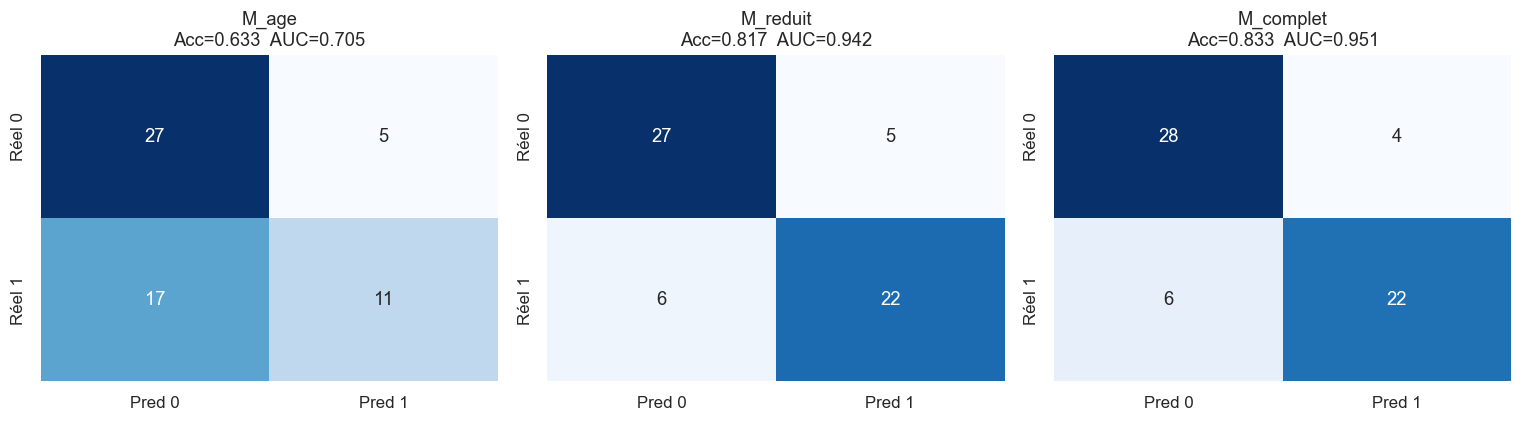

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, r in zip(axes, [eval_age, eval_red, eval_full]):
    sns.heatmap(r["cm"], annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Pred 0", "Pred 1"],
                yticklabels=["Réel 0", "Réel 1"], cbar=False)
    ax.set_title(f"{r['name']}\nAcc={r['acc']:.3f}  AUC={r['auc']:.3f}")
plt.tight_layout()
plt.savefig(os.path.join(FIG, "07_confusion_matrices.png"))
plt.show()

## 10. Interprétation : odds ratios du modèle retenu

$\mathrm{OR}_j = e^{\hat\beta_j}$ avec IC95 % $= \exp\!\big(\hat\beta_j \pm 1.96\,\hat\sigma_{\hat\beta_j}\big)$.

In [22]:
params = m_red.params
ci = m_red.conf_int()
or_table = pd.DataFrame({
    "Coefficient β": params,
    "OR = exp(β)": np.exp(params),
    "IC95% bas": np.exp(ci[0]),
    "IC95% haut": np.exp(ci[1]),
    "p-value": m_red.pvalues
}).round(4)
or_table.to_csv(os.path.join(ROOT, "odds_ratios.csv"))
or_table

,Coefficient β,OR = exp(β),IC95% bas,IC95% haut,p-value
const,-2.3709,0.0934,0.0293,0.2982,0.0001
trestbps,0.3749,1.4548,0.9770,2.1662,0.0650
oldpeak,0.6459,1.9077,1.1389,3.1955,0.0141
ca,0.8984,2.4557,1.5350,3.9288,0.0002
sex_M,0.8776,2.4051,0.9405,6.1505,0.0670
cp_asymptomatique,1.9151,6.7879,3.0986,14.8697,0.0000
restecg_normal,-0.7581,0.4685,0.2084,1.0533,0.0666
slope_plate,0.9217,2.5136,1.0666,5.9239,0.0351
thal_reversible,1.7150,5.5568,2.3723,13.0163,0.0001


## 11. Comparaison des fonctions de lien (logit / probit / cloglog)

In [23]:
links = {"logit": logit(), "probit": probit(), "cloglog": cloglog()}
for nm, lk in links.items():
    mdl = sm.GLM(y_train, X_train_sm[sel], family=Binomial(link=lk)).fit()
    print(f"  {nm:8s}  Déviance = {mdl.deviance:.3f}   AIC = {mdl.aic:.3f}")

  logit     Déviance = 168.195   AIC = 186.195
  probit    Déviance = 169.066   AIC = 187.066
  cloglog   Déviance = 167.634   AIC = 185.634


## Conclusion

Le modèle réduit (8 variables) atteint **AUC = 0.942** et **Accuracy ≈ 82 %**
sur l'échantillon de validation, avec une déviance conforme aux attentes
($D/ddl \approx 0.74$), un test de Hosmer-Lemeshow non-rejeté ($p=0.61$),
et des diagnostics résidus satisfaisants (aucune observation influente,
$\max D_{\text{Cook}} = 0.07 \ll 1$).

Les facteurs dominants sont le type de douleur asymptomatique
(OR ≈ 6.8), la thalassémie réversible (OR ≈ 5.6), le nombre de vaisseaux
coronariens touchés (OR ≈ 2.5) et la dépression du segment ST à l'effort
(OR ≈ 1.9).